# 07 — Typing Structure and Editing Behaviour (P2)

## What this covers that notebook 04 did not

Notebook 04 treated typing as a **timing** stream: press-to-press intervals, dwell, key
rate. That is a small part of what the keyboard logs. Untouched until now:

- **`payload_keyClass`** — a 7-way privacy-safe classification of every keystroke
  (LETTER, SPACE, BACKSPACE, DIGIT, ENTER, PUNCT_OR_SYMBOL, OTHER). This is P2's
  equivalent of P1's digraph timings, with the content stripped out, and it makes
  *class-transition* timing available: how long from a letter to the next letter, from a
  letter to a space, from one backspace to the next.
- **`payload_selectionStart` / `selectionEnd`** — caret position, which reveals whether
  someone repositions the cursor to fix a mistake or just deletes back to it.
- **`payload_repeat`** — whether a keystroke came from holding the key down. Holding
  backspace to wipe a field is a different behaviour from tapping it eleven times.
- **`beforeinput.inputType`** — insert, delete, replacement, line break.

Dwell time is deliberately absent from this notebook. Notebook 04 established that on a
touchscreen it is a platform constant (~10ms for nearly everyone); nothing here revisits
it.

## Why this is a promising seam

Correction behaviour has the widest raw spread of anything measured in this project. The
share of keystrokes that are backspaces runs from **0.8%** to **17.6%** — a factor of 22,
wider than any timing feature. And unlike most of what separates these participants, the
editing features are not obviously restatements of pace.

## What limits it

**There is not much typing.** Between 165 and 356 keydowns per participant across all
their sessions. Some of the features below rest on a handful of events — backspace *runs*
number 3 to 12 per person — and Section 7 reports support alongside every result rather
than burying it. Several measures that look promising are simply not yet testable, and
they are marked as such instead of being scored.

This is also why the analysis windows here are **30 seconds**, not the 7.5s used
elsewhere: at CA window size most windows contain no typing at all.


## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

RAW_EVENTS_PARQUET = "../../data/processed/raw_events.parquet"
RAW_EVENTS_CSV = "../../data/processed/raw_events.csv"
if Path(RAW_EVENTS_PARQUET).exists():
    raw_all = pd.read_parquet(RAW_EVENTS_PARQUET); _src = RAW_EVENTS_PARQUET
else:
    raw_all = pd.read_csv(RAW_EVENTS_CSV, low_memory=False); _src = RAW_EVENTS_CSV

raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

KEYDOWN, KEYUP, INPUT_KIND, BEFORE_INPUT = 'keydown', 'keyup', 'input', 'beforeinput'

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['observed_session_number'] = session_index.groupby('participantId').cumcount() + 1

_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANT_ORDER = _p_dur.index.astype(str).tolist()
PARTICIPANT_COLORS = {p: plt.get_cmap('turbo')((i + 0.5) / max(1, len(PARTICIPANT_ORDER)))
                      for i, p in enumerate(PARTICIPANT_ORDER)}
def pcolor(p): return PARTICIPANT_COLORS.get(str(p), '0.5')

keys = raw.loc[raw['kind'] == KEYDOWN].sort_values(['sessionId', 'tRelMs']).copy()
print(f"Loaded {_src}")
print(f"mobile: {raw['sessionId'].nunique()} sessions, {raw['participantId'].nunique()} participants")
print(f"keydown events: {len(keys):,}")

Loaded ../../data/processed/raw_events.parquet
mobile: 13 sessions, 6 participants
keydown events: 1,731


## 2. How much typing is there, really?

Every claim below is bounded by this table. Typing is a small fraction of the session —
Section 3 of notebook 04 established that only four of the fifteen task types afford it —
so features resting on rare events (backspace runs, caret repositioning) will have single
or low double-digit support.

The rule applied throughout: **report n next to every statistic, and refuse to score
anything below a stated minimum** rather than producing a confident-looking number from
five observations.

In [2]:
MIN_EVENTS_FOR_STAT = 20      # below this, report but do not score
MIN_EVENTS_FOR_AUC = 30       # below this, a per-participant AUC is not attempted

volume = (keys.groupby('participantId')
          .agg(keydowns=('rowId', 'size'), sessions=('sessionId', 'nunique'))
          .reindex(PARTICIPANT_ORDER))
volume['keydowns_per_session'] = (volume['keydowns'] / volume['sessions']).round(0)
_dur = session_index.groupby('participantId')['duration_s'].sum()
volume['keydowns_per_min'] = (volume['keydowns'] / (_dur.reindex(volume.index) / 60)).round(1)

print(volume.to_string())
print(f"\nTotal keydowns: {len(keys):,} across {keys['sessionId'].nunique()} sessions")
print(f"Thinnest participant: {volume['keydowns'].min():,} keystrokes total")
print("\n-> features below are scored at session level and in 30s windows, not 7.5s:")
print("   at CA window size most windows contain no typing at all.")

               keydowns  sessions  keydowns_per_session  keydowns_per_min
participantId                                                            
p3M6E7Z             165         1                 165.0              10.4
pH3S4X4             365         3                 122.0              13.5
pZMC82M             182         1                 182.0              25.1
p3YDMHG             268         2                 134.0              22.5
pA6XL23             283         2                 142.0              26.7
pG5G4MS             468         4                 117.0              49.4

Total keydowns: 1,731 across 13 sessions
Thinnest participant: 165 keystrokes total

-> features below are scored at session level and in 30s windows, not 7.5s:
   at CA window size most windows contain no typing at all.


## 3. Keystroke composition

The simplest possible feature and one of the most separating: what fraction of a person's
keystrokes are letters, spaces, backspaces.

Backspace share is the one to watch. It is a direct measure of how much of someone's
typing is spent undoing typing.

payload_keyClass  LETTER  SPACE  BACKSPACE  DIGIT  PUNCT_OR_SYMBOL  ENTER  OTHER
participantId                                                                   
p3M6E7Z             69.7   10.3       10.9    3.6              4.2    0.6    0.6
pH3S4X4             76.7    9.9        3.3    2.5              3.3    0.8    3.6
pZMC82M             61.0    8.2       17.6    4.9              2.7    1.1    4.4
p3YDMHG             69.0   10.1       11.2    3.0              3.4    0.0    3.4
pA6XL23             71.7   13.8        6.7    2.1              1.4    1.1    3.2
pG5G4MS             80.6   10.5        0.6    2.4              3.6    0.0    2.4


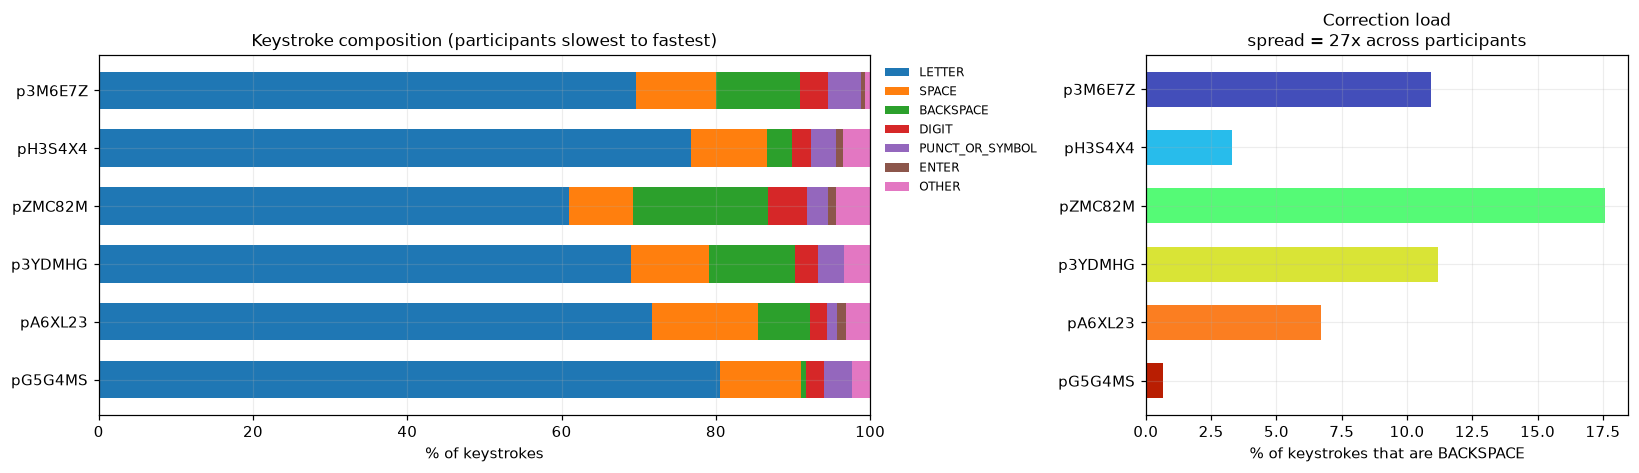

In [3]:
KEY_CLASSES = ['LETTER', 'SPACE', 'BACKSPACE', 'DIGIT', 'PUNCT_OR_SYMBOL', 'ENTER', 'OTHER']

composition = (pd.crosstab(keys['participantId'], keys['payload_keyClass'], normalize='index')
               .reindex(index=PARTICIPANT_ORDER)
               .reindex(columns=KEY_CLASSES, fill_value=0.0) * 100)


def plot_composition(comp):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={'width_ratios': [1.6, 1]})
    ax = axes[0]
    left = np.zeros(len(comp)); cmap = plt.get_cmap('tab20')
    for i, c in enumerate(comp.columns):
        ax.barh(range(len(comp)), comp[c], left=left, color=cmap(i * 2 % 20), label=c, height=0.65)
        left += comp[c].to_numpy()
    ax.set_yticks(range(len(comp))); ax.set_yticklabels(comp.index); ax.invert_yaxis()
    ax.set_xlim(0, 100); ax.set_xlabel("% of keystrokes")
    ax.set_title("Keystroke composition (participants slowest to fastest)")
    ax.legend(bbox_to_anchor=(1.005, 1), loc='upper left', frameon=False, fontsize=8)

    ax = axes[1]
    bs = comp['BACKSPACE']
    ax.barh(range(len(bs)), bs, color=[pcolor(p) for p in bs.index], height=0.6)
    ax.set_yticks(range(len(bs))); ax.set_yticklabels(bs.index); ax.invert_yaxis()
    ax.set_xlabel("% of keystrokes that are BACKSPACE")
    ax.set_title(f"Correction load\nspread = {bs.max() / max(bs.min(), 0.01):.0f}x across participants")
    plt.tight_layout(); plt.show(); plt.close(fig)


print(composition.round(1).to_string())
plot_composition(composition)

## 4. Key-class transitions — the digraph substitute

P1 used literal digraph timings (`th`, `he`, `in`, `er`), which required retaining what
was typed. P2 cannot do that and should not want to. The class transition is the
privacy-preserving equivalent: the time from a LETTER to the next LETTER carries the same
kind of motor information as a specific letter pair, without the content.

Three transitions are worth separating conceptually:

- **LETTER→LETTER** is typing speed proper.
- **LETTER→SPACE** and **SPACE→LETTER** straddle word boundaries, where lexical decisions
  happen rather than pure motor execution.
- **BACKSPACE→BACKSPACE** is deletion speed, which is a different motor act entirely and
  need not correlate with typing speed.

Transitions longer than `MAX_TRANSITION_MS` are dropped: they span a pause rather than a
keystroke pair, and would otherwise import the hesitation signal notebook 04 already
measures.

In [4]:
MAX_TRANSITION_MS = 3000.0

TRANSITIONS_OF_INTEREST = ['LETTER->LETTER', 'LETTER->SPACE', 'SPACE->LETTER',
                           'BACKSPACE->BACKSPACE', 'LETTER->BACKSPACE', 'DIGIT->DIGIT']


def build_transitions(keys_df, max_ms=MAX_TRANSITION_MS):
    rows = []
    for (pid, sid), g in keys_df.groupby(['participantId', 'sessionId']):
        g = g.sort_values('tRelMs')
        k = g['payload_keyClass'].astype(str).to_numpy()
        t = g['tRelMs'].to_numpy(float)
        comp = g['payload_componentId'].astype(str).to_numpy()
        for i in range(len(k) - 1):
            dt = t[i + 1] - t[i]
            if not (0 < dt <= max_ms):
                continue
            rows.append({'participantId': pid, 'sessionId': sid, 't_rel_s': t[i] / 1000.0,
                         'transition': f"{k[i]}->{k[i + 1]}", 'dt_ms': dt,
                         'componentId': comp[i]})
    return pd.DataFrame(rows)


transitions = build_transitions(keys)

_piv = (transitions.loc[transitions['transition'].isin(TRANSITIONS_OF_INTEREST)]
        .pivot_table(index='participantId', columns='transition', values='dt_ms', aggfunc='median')
        .reindex(index=PARTICIPANT_ORDER, columns=TRANSITIONS_OF_INTEREST))
_n = (transitions.loc[transitions['transition'].isin(TRANSITIONS_OF_INTEREST)]
      .pivot_table(index='participantId', columns='transition', values='dt_ms', aggfunc='size')
      .reindex(index=PARTICIPANT_ORDER, columns=TRANSITIONS_OF_INTEREST))

print("Median transition time (ms), with n underneath. Blank = never observed.\n")
print(_piv.round(0).to_string())
print("\nsupport (n):")
print(_n.fillna(0).astype(int).to_string())
_thin = [c for c in TRANSITIONS_OF_INTEREST if (_n[c].fillna(0) < MIN_EVENTS_FOR_STAT).any()]
if _thin:
    print(f"\nBelow {MIN_EVENTS_FOR_STAT} for at least one participant, so not scored later: "
          f"{', '.join(_thin)}")

Median transition time (ms), with n underneath. Blank = never observed.

transition     LETTER->LETTER  LETTER->SPACE  SPACE->LETTER  BACKSPACE->BACKSPACE  LETTER->BACKSPACE  DIGIT->DIGIT
participantId                                                                                                     
p3M6E7Z                 433.0          274.0          442.0                 100.0             2729.0         425.0
pH3S4X4                 400.0          284.0          837.0                 211.0             2111.0         346.0
pZMC82M                 135.0          106.0          171.0                 150.0              415.0         239.0
p3YDMHG                 350.0          349.0          400.0                 101.0              620.0         386.0
pA6XL23                 148.0          162.0          184.0                 148.0              357.0         136.0
pG5G4MS                 167.0          100.0          198.0                   NaN              366.0         116.0

suppor

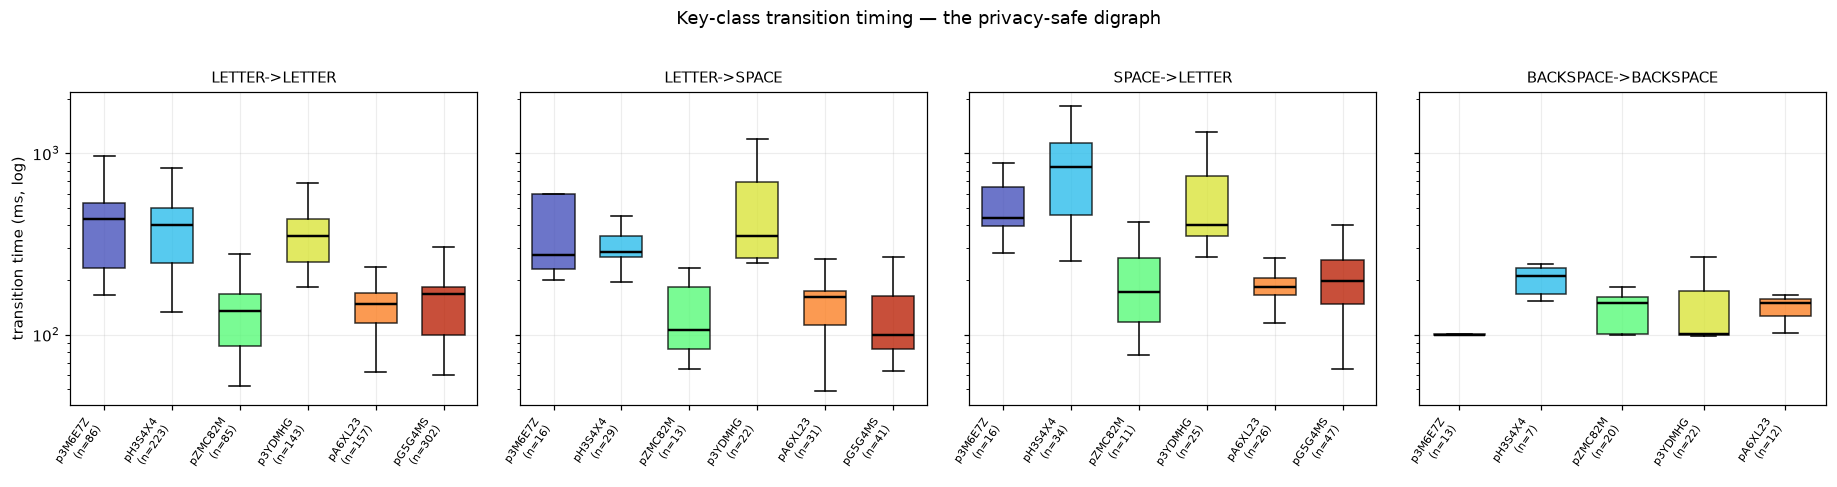

In [5]:
def plot_transitions(trans, which=('LETTER->LETTER', 'LETTER->SPACE',
                                   'SPACE->LETTER', 'BACKSPACE->BACKSPACE')):
    fig, axes = plt.subplots(1, len(which), figsize=(4.2 * len(which), 4.3), sharey=True)
    for ax, tr in zip(np.atleast_1d(axes), which):
        data, labels, colors = [], [], []
        for p in PARTICIPANT_ORDER:
            v = trans.loc[(trans['participantId'] == p) & (trans['transition'] == tr), 'dt_ms']
            v = v.to_numpy(float)
            if len(v) < 5:
                continue
            data.append(v); labels.append(f"{p}\n(n={len(v)})"); colors.append(pcolor(p))
        if not data:
            ax.set_title(f"{tr}\nno data"); ax.set_axis_off(); continue
        bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.62,
                        medianprops={'color': 'black', 'lw': 1.6})
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c); patch.set_alpha(0.78)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=7)
        ax.set_yscale('log'); ax.set_title(tr, fontsize=10)
    axes[0].set_ylabel("transition time (ms, log)")
    fig.suptitle("Key-class transition timing — the privacy-safe digraph", y=1.02)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_transitions(transitions)

## 5. Editing behaviour

Four measures of *how* someone corrects, as distinct from how often:

- **`backspace_run_length`** — consecutive deletions in one go. Deleting a single
  mistyped character is a different act from wiping a whole field and starting again.
- **`key_autorepeat_rate`** — the share of keystrokes flagged `payload_repeat`, meaning
  the key was *held* rather than pressed. Holding backspace to clear a field versus
  tapping it repeatedly is a strategy choice, and it turns out to split this cohort
  cleanly.
- **`caret_repositioned_rate`** — from `payload_selectionStart` against
  `payload_valueLength`: the caret sitting before the end of the text means the person
  navigated into it rather than deleting back to the error.
- **`chars_before_noticing`** — keystrokes typed between the start of a run and the first
  backspace. An error-monitoring measure, and the thinnest of the four.

In [6]:
def editing_features(keys_df):
    rows = []
    for (pid, sid), g in keys_df.groupby(['participantId', 'sessionId']):
        g = g.sort_values('tRelMs')
        k = g['payload_keyClass'].astype(str).to_numpy()
        n = len(k)
        if n == 0:
            continue
        # runs of consecutive backspaces
        runs, cur = [], 0
        for x in k:
            if x == 'BACKSPACE':
                cur += 1
            elif cur:
                runs.append(cur); cur = 0
        if cur:
            runs.append(cur)
        # keystrokes typed before the first deletion of each run
        gaps, since = [], 0
        for x in k:
            if x == 'BACKSPACE':
                if since > 0:
                    gaps.append(since)
                since = -1
            since += 1

        sel = pd.to_numeric(g['payload_selectionStart'], errors='coerce')
        vln = pd.to_numeric(g['payload_valueLength'], errors='coerce')
        repositioned = ((sel.notna()) & (vln.notna()) & (sel < vln - 1))
        rep = g['payload_repeat']
        rep = rep.astype(str).str.lower().isin(['true', '1', '1.0'])

        rows.append({
            'participantId': pid, 'sessionId': sid, 'n_keys': n,
            'backspace_share': float((k == 'BACKSPACE').mean()),
            'letter_share': float((k == 'LETTER').mean()),
            'backspace_run_length': float(np.mean(runs)) if runs else np.nan,
            'backspace_run_max': float(np.max(runs)) if runs else np.nan,
            'n_runs': len(runs),
            'key_autorepeat_rate': float(rep.mean()),
            'caret_repositioned_rate': float(repositioned.mean()),
            'chars_before_noticing': float(np.median(gaps)) if gaps else np.nan,
            'n_gaps': len(gaps),
        })
    return pd.DataFrame(rows)


editing = editing_features(keys)
EDIT_FEATURES = ['backspace_share', 'letter_share', 'backspace_run_length',
                 'key_autorepeat_rate', 'caret_repositioned_rate', 'chars_before_noticing']

summary = (editing.groupby('participantId')[EDIT_FEATURES + ['n_keys', 'n_runs', 'n_gaps']]
           .agg({**{f: 'median' for f in EDIT_FEATURES},
                 'n_keys': 'sum', 'n_runs': 'sum', 'n_gaps': 'sum'})
           .reindex(PARTICIPANT_ORDER))
print(summary.round(3).to_string())

_thin = summary.loc[summary['n_runs'] < MIN_EVENTS_FOR_STAT]
if len(_thin):
    print(f"\nWARNING: backspace runs number {summary['n_runs'].min():.0f}-"
          f"{summary['n_runs'].max():.0f} per participant, below the {MIN_EVENTS_FOR_STAT} "
          f"threshold.\n         run-length and chars_before_noticing are reported but NOT scored.")

               backspace_share  letter_share  backspace_run_length  key_autorepeat_rate  caret_repositioned_rate  chars_before_noticing  n_keys  n_runs  n_gaps
participantId                                                                                                                                                  
p3M6E7Z                  0.109         0.697                 3.600                0.079                    0.036                  14.00     165       5       5
pH3S4X4                  0.017         0.790                 2.250                0.000                    0.000                  17.50     365       5       5
pZMC82M                  0.176         0.610                 2.667                0.044                    0.000                   9.50     182      12      12
p3YDMHG                  0.112         0.690                 5.400                0.063                    0.007                  19.00     268       7       7
pA6XL23                  0.064         0

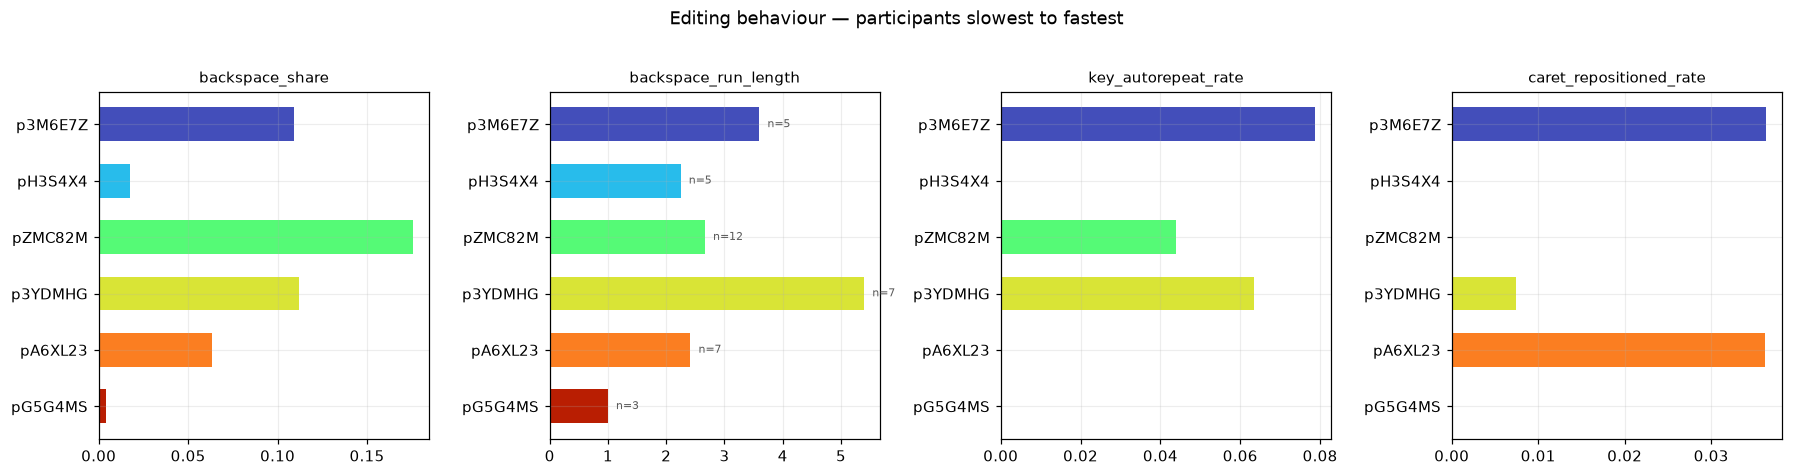

In [7]:
def plot_editing(summ, edit_df):
    feats = ['backspace_share', 'backspace_run_length', 'key_autorepeat_rate',
             'caret_repositioned_rate']
    fig, axes = plt.subplots(1, len(feats), figsize=(4.1 * len(feats), 4.2))
    for ax, f in zip(np.atleast_1d(axes), feats):
        v = summ[f].dropna()
        ax.barh(range(len(v)), v, color=[pcolor(p) for p in v.index], height=0.6)
        ax.set_yticks(range(len(v))); ax.set_yticklabels(v.index); ax.invert_yaxis()
        ax.set_title(f, fontsize=10)
        n_col = {'backspace_run_length': 'n_runs'}.get(f)
        if n_col:
            for i, p in enumerate(v.index):
                ax.text(v.loc[p], i, f"  n={int(summ.loc[p, n_col])}", va='center', fontsize=7,
                        color='0.35')
    fig.suptitle("Editing behaviour — participants slowest to fastest", y=1.02)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_editing(summary, editing)

## 6. Does the task confound the editing features?

The tasks require typing specific content, and the amount of it is not identical every
time — `typing_search` produces anywhere from 5 to 16 characters. That matters, because if
longer prompts elicit more mistakes then `backspace_share` would partly be measuring
**which text someone was asked to type** rather than how they type.

Three checks below, then the fix.

1. **Is the amount typed systematic by participant?** If one person consistently types
   more, their correction rate is not comparable to anyone else's.
2. **Does correction rate track text length within a task?** The direct test of the
   confound.
3. **Does the ranking survive inside each task type?** If pZMC82M is the heaviest corrector
   in every task separately, the effect is not a task artefact.

In [8]:
_ts = raw.loc[raw['kind'] == 'task_start',
              ['sessionId', 'taskIndex', 'payload_taskType', 'tRelMs']].rename(
    columns={'payload_taskType': 'taskType', 'tRelMs': 'task_start_ms'})
_te = raw.loc[raw['kind'] == 'task_end', ['sessionId', 'taskIndex', 'tRelMs']].rename(
    columns={'tRelMs': 'task_end_ms'})
task_timeline = _ts.merge(_te, on=['sessionId', 'taskIndex'], how='inner')
task_timeline['taskIndex'] = pd.to_numeric(task_timeline['taskIndex'], errors='coerce')

inputs = raw.loc[raw['kind'] == INPUT_KIND].copy()
inputs['value_length'] = pd.to_numeric(inputs['payload_valueLength'], errors='coerce')
inputs['delta_length'] = pd.to_numeric(inputs['payload_deltaLength'], errors='coerce')

MIN_KEYS_PER_TASK, MIN_CHARS_PER_TASK = 5, 3


def per_task_typing(keys_df, inputs_df, timeline):
    '''One row per task instance that contained typing.'''
    rows = []
    for sid, tl in timeline.groupby('sessionId'):
        k = keys_df.loc[keys_df['sessionId'] == sid]
        i = inputs_df.loc[inputs_df['sessionId'] == sid]
        for r in tl.itertuples():
            mk = (k['tRelMs'] >= r.task_start_ms) & (k['tRelMs'] < r.task_end_ms)
            mi = (i['tRelMs'] >= r.task_start_ms) & (i['tRelMs'] < r.task_end_ms)
            if mk.sum() < MIN_KEYS_PER_TASK or mi.sum() == 0:
                continue
            kk = k.loc[mk]
            final_len = i.loc[mi, 'value_length'].max()
            if not np.isfinite(final_len) or final_len < MIN_CHARS_PER_TASK:
                continue
            n_keys = int(mk.sum())
            cls = kk['payload_keyClass'].astype(str)
            rows.append({'participantId': kk['participantId'].iloc[0], 'sessionId': sid,
                         'taskIndex': int(r.taskIndex), 'taskType': r.taskType,
                         'n_keys': n_keys, 'final_len': float(final_len),
                         'keys_per_char': n_keys / float(final_len),
                         'backspace_share': float((cls == 'BACKSPACE').mean()),
                         'letter_share': float((cls == 'LETTER').mean())})
    return pd.DataFrame(rows)


task_typing = per_task_typing(keys, inputs, task_timeline)

print("CHECK 1 — is the amount typed systematic by participant?\n")
_len = task_typing.pivot_table(index='participantId', columns='taskIndex', values='final_len')
print(_len.round(0).reindex(PARTICIPANT_ORDER).to_string())
_mean = task_typing.groupby('participantId')['final_len'].mean().reindex(PARTICIPANT_ORDER)
print(f"\nmean characters typed: {_mean.round(1).to_dict()}")
print(f"spread across participants: {_mean.max() / _mean.min():.2f}x "
      f"-> {'NOT systematic; comparable' if _mean.max() / _mean.min() < 1.5 else 'SYSTEMATIC; must normalise'}")

print("\n\nCHECK 2 — does correction rate track text length, within task?\n")
for tt, g in task_typing.groupby('taskType'):
    if len(g) < 8:
        continue
    r = g[['backspace_share', 'final_len']].corr().iloc[0, 1]
    print(f"  {tt:16s} n={len(g):3d}  r={r:+.2f}")
_pool = task_typing[['backspace_share', 'final_len']].corr().iloc[0, 1]
print(f"  {'pooled':16s} n={len(task_typing):3d}  r={_pool:+.2f}"
      f"   -> {'no length confound' if abs(_pool) < 0.4 else 'LENGTH CONFOUND PRESENT'}")

print("\n\nCHECK 3 — does the ranking survive inside each task type?\n")
_bt = task_typing.pivot_table(index='participantId', columns='taskType',
                              values='backspace_share').reindex(PARTICIPANT_ORDER)
print(_bt.round(3).to_string())
_ranks = _bt.rank()
print(f"\nrank correlation between task types: "
      f"{_ranks.corr().to_numpy()[np.triu_indices(len(_ranks.columns), 1)].mean():.2f}")
print("A high value means the same people correct most regardless of task.")

CHECK 1 — is the amount typed systematic by participant?

taskIndex        3     7     13   14    18    24
participantId                                   
p3M6E7Z         8.0  14.0  34.0  7.0  11.0  30.0
pH3S4X4         9.0  14.0  32.0  5.0  15.0  31.0
pZMC82M         5.0  14.0  38.0  5.0  15.0  35.0
p3YDMHG         5.0  14.0  36.0  4.0  16.0  30.0
pA6XL23         7.0  18.0  34.0  8.0  14.0  34.0
pG5G4MS        12.0  12.0  33.0  8.0  14.0  33.0

mean characters typed: {'p3M6E7Z': 17.3, 'pH3S4X4': 17.7, 'pZMC82M': 18.7, 'p3YDMHG': 17.7, 'pA6XL23': 19.1, 'pG5G4MS': 19.0}
spread across participants: 1.10x -> NOT systematic; comparable


CHECK 2 — does correction rate track text length, within task?

  guided_note      n= 26  r=+0.02
  guided_reply     n= 26  r=+0.07
  typing_search    n= 25  r=-0.12
  pooled           n= 77  r=-0.13   -> no length confound


CHECK 3 — does the ranking survive inside each task type?

taskType       guided_note  guided_reply  typing_search
participantId   

### 6.1 The fix: normalise by text, condition on task

Two changes follow from the checks.

**`keys_per_char`** — keystrokes per character of finished text — normalises effort by how
much text the task actually demanded. It also counts *all* wasted keystrokes rather than
only deletions, so a person who retypes a word without deleting it is measured too.

**Task-conditioned shares.** Even though text length does not drive the correction rate,
the task type shifts its *level* — `guided_note` elicits several times the correction rate
of `guided_reply` for everyone. Pooling across tasks therefore imports between-task
variance that has nothing to do with identity. Z-scoring within task type removes it.

One unplanned result falls out. `keys_per_char` below 1 means more characters appeared
than keys were pressed, which is only possible if the keyboard supplied some — a
suggestion or a paste. That is a working **predictive-text detector**, and it is the
feature Section 7 fails to build from `beforeinput.dataLength`.

In [9]:
def zscore_within(df, feature, by='taskType'):
    g = df.groupby(by)[feature]
    mu, sd = g.transform('mean'), g.transform('std')
    return (df[feature] - mu) / sd.replace(0, np.nan)


task_typing['backspace_share_task_z'] = zscore_within(task_typing, 'backspace_share')
task_typing['keys_per_char_task_z'] = zscore_within(task_typing, 'keys_per_char')
task_typing['keyboard_assisted'] = (task_typing['keys_per_char'] < 1.0)

_summ = (task_typing.groupby('participantId')
         .agg(n_tasks=('keys_per_char', 'size'),
              keys_per_char=('keys_per_char', 'median'),
              backspace_share=('backspace_share', 'median'),
              backspace_share_task_z=('backspace_share_task_z', 'median'),
              keyboard_assisted_rate=('keyboard_assisted', 'mean'))
         .reindex(PARTICIPANT_ORDER))
print("Length-normalised and task-conditioned typing effort:\n")
print(_summ.round(3).to_string())

_assist = _summ['keyboard_assisted_rate']
if (_assist > 0).any():
    print(f"\nkeys_per_char < 1 (keyboard supplied characters) occurs for "
          f"{(_assist > 0).sum()}/{len(_assist)} participants")
    print("-> this is the predictive-text detector that Section 7's dataLength approach misses.")

print("\nkeys_per_char within each task type (task-level shifts visible):")
print(task_typing.pivot_table(index='participantId', columns='taskType',
                              values='keys_per_char').reindex(PARTICIPANT_ORDER).round(2).to_string())

Length-normalised and task-conditioned typing effort:

               n_tasks  keys_per_char  backspace_share  backspace_share_task_z  keyboard_assisted_rate
participantId                                                                                         
p3M6E7Z              6          1.091            0.054                   0.056                   0.333
pH3S4X4             18          1.034            0.000                  -0.613                   0.056
pZMC82M              6          1.467            0.146                   1.382                   0.000
p3YDMHG             12          1.177            0.016                  -0.264                   0.250
pA6XL23             12          1.134            0.000                  -0.463                   0.000
pG5G4MS             23          1.027            0.000                  -0.613                   0.043

keys_per_char < 1 (keyboard supplied characters) occurs for 4/6 participants
-> this is the predictive-text detector tha

## 7. Two ideas that do not work here

Recorded rather than dropped, so they are not re-derived later.

**Predictive text usage.** `beforeinput` distinguishes `insertText` from
`insertReplacementText`, and a multi-character insertion should mark a keyboard suggestion
being accepted rather than characters being typed. It sounded like a strong style marker —
some people lean on autocomplete, some ignore it.

**Error-detection latency.** Keystrokes typed before noticing a mistake is a genuine
cognitive measure, but with 3 to 12 backspace runs per participant the median rests on
single figures.

The cell below quantifies both. Neither is a negative result about the *behaviour* —
both are negative results about the amount of typing this task collects.

Note that Section 6.1 recovers the first of them by a different route: `keys_per_char < 1`
detects keyboard-supplied characters without needing `dataLength` to be informative.

In [10]:
bi = raw.loc[raw['kind'] == BEFORE_INPUT].copy()
if len(bi):
    bi['data_len'] = pd.to_numeric(bi['payload_dataLength'], errors='coerce')
    pred = []
    for p in PARTICIPANT_ORDER:
        g = bi.loc[bi['participantId'] == p]
        if not len(g):
            continue
        ins = g.loc[g['payload_inputType'] == 'insertText']
        pred.append({'participantId': p, 'n_beforeinput': len(g),
                     'multi_char_insert_rate': float((ins['data_len'] > 1).mean()) if len(ins) else np.nan,
                     'replacement_rate': float((g['payload_inputType'] == 'insertReplacementText').mean())})
    predictive = pd.DataFrame(pred).set_index('participantId')
    print("Predictive-text usage:\n")
    print(predictive.round(4).to_string())
    _spread = predictive['replacement_rate'].max() - predictive['replacement_rate'].min()
    print(f"\n  multi-char insertions: {predictive['multi_char_insert_rate'].max():.3f} at most "
          f"-> essentially nobody accepts multi-character suggestions")
    print(f"  replacement rate spread: {_spread:.3f} across participants")
    print("  -> REJECTED: too little variation to separate anyone.")
    print("     Not evidence that autocomplete style is uninformative in general — only that")
    print("     these four short input fields do not elicit enough of it to measure.")

print(f"\nError-detection latency support: "
      f"{summary['n_gaps'].min():.0f}-{summary['n_gaps'].max():.0f} runs per participant")
print("  -> REPORTED, NOT SCORED. Revisit if a future task design includes more free text.")

Predictive-text usage:

               n_beforeinput  multi_char_insert_rate  replacement_rate
participantId                                                         
p3M6E7Z                  171                  0.0068            0.0234
pH3S4X4                  356                  0.0029            0.0112
pZMC82M                  176                  0.0000            0.0227
p3YDMHG                  267                  0.0000            0.0150
pA6XL23                  282                  0.0000            0.0390
pG5G4MS                  464                  0.0000            0.0129

  multi-char insertions: 0.007 at most -> essentially nobody accepts multi-character suggestions
  replacement rate spread: 0.028 across participants
  -> REJECTED: too little variation to separate anyone.
     Not evidence that autocomplete style is uninformative in general — only that
     these four short input fields do not elicit enough of it to measure.

Error-detection latency support: 3-12 runs p

## 8. Verdict

Same two tests used in notebooks 05 and 06, plus a support gate that this notebook needs
more than the others.

Features are scored at **session level** and in **30-second windows**. A 7.5s CA window
usually contains no typing, so scoring there would mostly measure whether the person
happened to be in a typing task — which notebook 04's affordance masking already handles
better.

The support gate matters: anything resting on fewer than the stated minimum is returned as
`NO EVIDENCE` rather than being given a number that looks like a result.

In [11]:
TYPING_WINDOW_S, TYPING_STRIDE_S = 30.0, 10.0
MIN_KEYS_PER_WINDOW = 8
PACE_PROXY_R, MEAN_AUC_MIN = 0.70, 0.60


def rank_auc(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    x = x[np.isfinite(x)]; y = y[np.isfinite(y)]
    if len(x) < 5 or len(y) < 5:
        return np.nan
    ranks = pd.Series(np.concatenate([x, y])).rank(method='average').to_numpy()
    return float((ranks[:len(x)].sum() - len(x) * (len(x) + 1) / 2) / (len(x) * len(y)))


def pairwise(df, feature):
    parts = [p for p in PARTICIPANT_ORDER if p in set(df['participantId'])]
    vals = {p: df.loc[df['participantId'] == p, feature].to_numpy(float) for p in parts}
    out = {}
    for i, a in enumerate(parts):
        for b in parts[i + 1:]:
            v = rank_auc(vals[a], vals[b])
            if np.isfinite(v):
                out[(a, b)] = max(v, 1 - v)
    return out


def typing_windows(keys_df, trans_df):
    '''30s windows containing enough keystrokes to describe typing.'''
    rows = []
    for (pid, sid), g in keys_df.groupby(['participantId', 'sessionId']):
        g = g.sort_values('tRelMs')
        t = g['tRelMs'].to_numpy(float) / 1000.0
        k = g['payload_keyClass'].astype(str).to_numpy()
        rep_arr = g['payload_repeat'].astype(str).str.lower().isin(['true', '1', '1.0']).to_numpy()
        _sel = pd.to_numeric(g['payload_selectionStart'], errors='coerce')
        _vln = pd.to_numeric(g['payload_valueLength'], errors='coerce')
        caret_arr = ((_sel.notna()) & (_vln.notna()) & (_sel < _vln - 1)).to_numpy()
        tr = trans_df.loc[(trans_df['participantId'] == pid) & (trans_df['sessionId'] == sid)]
        end = t.max() if len(t) else 0.0
        lo = 0.0
        while lo + TYPING_WINDOW_S <= end + TYPING_STRIDE_S:
            m = (t >= lo) & (t < lo + TYPING_WINDOW_S)
            if m.sum() >= MIN_KEYS_PER_WINDOW:
                kk = k[m]
                tm = tr.loc[(tr['t_rel_s'] >= lo) & (tr['t_rel_s'] < lo + TYPING_WINDOW_S)]
                ll = tm.loc[tm['transition'] == 'LETTER->LETTER', 'dt_ms']
                # Autorepeat and caret position are rates over keystrokes, so they are
                # computable per window. Computing them only per session would leave
                # 9 values total -- too few for an AUC, which would read as "no evidence"
                # when the truth is "wrong granularity".
                rows.append({'participantId': pid, 'sessionId': sid, 'window_start_s': lo,
                             'n_keys': int(m.sum()),
                             'backspace_share': float((kk == 'BACKSPACE').mean()),
                             'letter_share': float((kk == 'LETTER').mean()),
                             'key_autorepeat_rate': float(rep_arr[m].mean()),
                             'caret_repositioned_rate': float(caret_arr[m].mean()),
                             'letter_letter_ms': float(ll.median()) if len(ll) >= 3 else np.nan})
            lo += TYPING_STRIDE_S
    return pd.DataFrame(rows)


win = typing_windows(keys, transitions)
_dur = session_index.groupby('participantId')['duration_s'].median()

_n_tasks = task_typing.groupby('participantId').size().reindex(PARTICIPANT_ORDER)

CANDIDATES = {
    'backspace_share': ('session+window', editing, win, summary['n_keys']),
    'letter_share': ('session+window', editing, win, summary['n_keys']),
    'key_autorepeat_rate': ('session+window', editing, win, summary['n_keys']),
    'caret_repositioned_rate': ('session+window', editing, win, summary['n_keys']),
    'backspace_run_length': ('session', editing, None, summary['n_runs']),
    'chars_before_noticing': ('session', editing, None, summary['n_gaps']),
    # length-normalised and task-conditioned, from Section 6.1
    'keys_per_char': ('task', task_typing, task_typing, summary['n_keys']),
    'backspace_share_task_z': ('task', task_typing, task_typing, summary['n_keys']),
    'keys_per_char_task_z': ('task', task_typing, task_typing, summary['n_keys']),
}

_rows = []
for feat, (level, sess_df, win_df, support) in CANDIDATES.items():
    s_sess = pairwise(sess_df, feat) if feat in sess_df else {}
    s_win = pairwise(win_df, feat) if (win_df is not None and feat in win_df) else {}
    med = sess_df.groupby('participantId')[feat].median()
    common = med.index.intersection(_dur.index)
    r = float(np.corrcoef(_dur[common], med[common])[0, 1]) \
        if len(common) > 2 and med[common].nunique() > 1 else np.nan
    _rows.append({'feature': feat, 'level': level, 'min_support': float(support.min()),
                  'session_mean': np.mean(list(s_sess.values())) if s_sess else np.nan,
                  'window_mean': np.mean(list(s_win.values())) if s_win else np.nan,
                  'window_min': np.min(list(s_win.values())) if s_win else np.nan,
                  'pace_r': r})

# transition timings scored on their own events
for tr in ['LETTER->LETTER', 'LETTER->SPACE', 'SPACE->LETTER', 'BACKSPACE->BACKSPACE']:
    d = transitions.loc[transitions['transition'] == tr]
    n_min = d.groupby('participantId').size().min() if len(d) else 0
    s = pairwise(d, 'dt_ms')
    med = d.groupby('participantId')['dt_ms'].median()
    common = med.index.intersection(_dur.index)
    r = float(np.corrcoef(_dur[common], med[common])[0, 1]) if len(common) > 2 else np.nan
    _rows.append({'feature': f"dt[{tr}]", 'level': 'event', 'min_support': float(n_min),
                  'session_mean': np.nan,
                  'window_mean': np.mean(list(s.values())) if s else np.nan,
                  'window_min': np.min(list(s.values())) if s else np.nan, 'pace_r': r})

scores = pd.DataFrame(_rows)


def decide(r):
    if r['min_support'] < MIN_EVENTS_FOR_AUC:
        return 'NO EVIDENCE', f"only {r['min_support']:.0f} events for the thinnest participant"
    best = r['window_mean'] if np.isfinite(r['window_mean']) else r['session_mean']
    if not np.isfinite(best):
        return 'NO EVIDENCE', 'AUC not estimable'
    if best < MEAN_AUC_MIN:
        return 'EXCLUDE', 'does not separate'
    if np.isfinite(r['pace_r']) and abs(r['pace_r']) >= PACE_PROXY_R:
        return 'HOLD', f"pace proxy (r={r['pace_r']:+.2f})"
    return 'INCLUDE', f"separates and is pace-independent (r={r['pace_r']:+.2f})"


scores[['decision', 'reason']] = scores.apply(lambda r: pd.Series(decide(r)), axis=1)
scores = scores.sort_values(['decision', 'window_mean'], ascending=[True, False]).reset_index(drop=True)

print(f"{len(win):,} typing windows of {TYPING_WINDOW_S:.0f}s "
      f"with >= {MIN_KEYS_PER_WINDOW} keystrokes\n")
for d in ['INCLUDE', 'HOLD', 'EXCLUDE', 'NO EVIDENCE']:
    sub = scores.loc[scores['decision'] == d]
    if sub.empty:
        continue
    print(f"{d}:")
    for r in sub.itertuples():
        best = r.window_mean if np.isfinite(r.window_mean) else r.session_mean
        b = f"{best:.3f}" if np.isfinite(best) else "  n/a"
        print(f"   {r.feature:26s} AUC {b}  (support {r.min_support:.0f})  -> {r.reason}")
    print()
scores.round(3)

183 typing windows of 30s with >= 8 keystrokes

INCLUDE:
   backspace_share_task_z     AUC 0.710  (support 165)  -> separates and is pace-independent (r=+0.23)
   letter_share               AUC 0.688  (support 165)  -> separates and is pace-independent (r=-0.29)
   backspace_share            AUC 0.673  (support 165)  -> separates and is pace-independent (r=+0.35)
   keys_per_char              AUC 0.665  (support 165)  -> separates and is pace-independent (r=-0.02)
   keys_per_char_task_z       AUC 0.664  (support 165)  -> separates and is pace-independent (r=-0.06)

HOLD:
   dt[LETTER->LETTER]         AUC 0.792  (support 85)  -> pace proxy (r=+0.71)

EXCLUDE:
   key_autorepeat_rate        AUC 0.549  (support 165)  -> does not separate
   caret_repositioned_rate    AUC 0.523  (support 165)  -> does not separate

NO EVIDENCE:
   dt[LETTER->SPACE]          AUC 0.821  (support 13)  -> only 13 events for the thinnest participant
   dt[SPACE->LETTER]          AUC 0.802  (support 11)  -> only

,feature,level,min_support,session_mean,window_mean,window_min,pace_r,decision,reason
0,key_autorepeat_rate,session+window,165.0,NaN,0.549,0.500,0.656,EXCLUDE,does not separate
1,caret_repositioned_rate,session+window,165.0,NaN,0.523,0.500,0.503,EXCLUDE,does not separate
2,dt[LETTER->LETTER],event,85.0,NaN,0.792,0.526,0.710,HOLD,pace proxy (r=+0.71)
3,backspace_share_task_z,task,165.0,0.710,0.710,0.528,0.228,INCLUDE,separates and is pace-independent (r=+0.23)
4,letter_share,session+window,165.0,NaN,0.688,0.502,-0.289,INCLUDE,separates and is pace-independent (r=-0.29)
5,backspace_share,session+window,165.0,NaN,0.673,0.523,0.350,INCLUDE,separates and is pace-independent (r=+0.35)
6,keys_per_char,task,165.0,0.665,0.665,0.521,-0.024,INCLUDE,separates and is pace-independent (r=-0.02)
7,keys_per_char_task_z,task,165.0,0.664,0.664,0.507,-0.055,INCLUDE,separates and is pace-independent (r=-0.06)
8,dt[LETTER->SPACE],event,13.0,NaN,0.821,0.502,0.462,NO EVIDENCE,only 13 events for the thinnest participant
9,dt[SPACE->LETTER],event,11.0,NaN,0.802,0.552,0.417,NO EVIDENCE,only 11 events for the thinnest participant


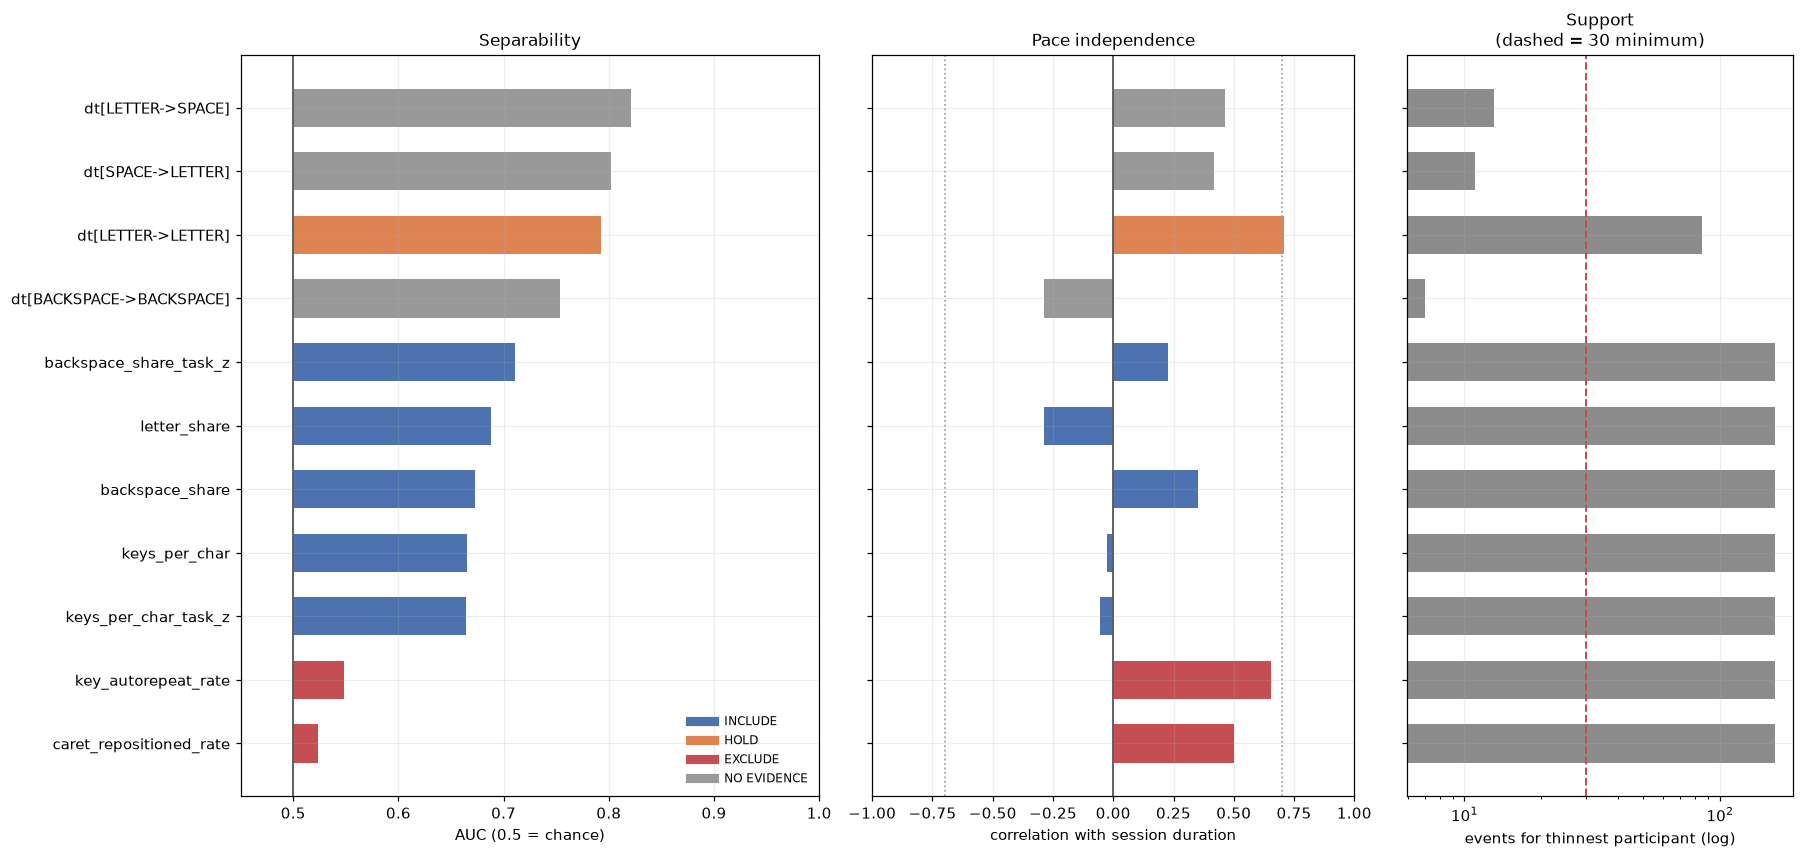

In [12]:
def plot_verdict(sc):
    d = sc.copy()
    d['best'] = d['window_mean'].fillna(d['session_mean'])
    d = d.dropna(subset=['best']).sort_values('best')
    if d.empty:
        print("nothing scoreable"); return
    y = np.arange(len(d))
    cmap = {'INCLUDE': '#4c72b0', 'HOLD': '#dd8452', 'EXCLUDE': '#c44e52', 'NO EVIDENCE': '0.6'}
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 0.5 * len(d) + 2.4),
                             gridspec_kw={'width_ratios': [1.2, 1, 0.8]})
    ax = axes[0]
    ax.barh(y, d['best'] - 0.5, left=0.5, height=0.6, color=[cmap[v] for v in d['decision']])
    ax.axvline(0.5, color='0.35', lw=1.2)
    ax.set_yticks(y); ax.set_yticklabels(d['feature']); ax.set_xlim(0.45, 1.0)
    ax.set_xlabel("AUC (0.5 = chance)"); ax.set_title("Separability")

    ax = axes[1]
    ax.barh(y, d['pace_r'].fillna(0), height=0.6, color=[cmap[v] for v in d['decision']])
    ax.axvline(0, color='0.35', lw=1.2)
    for x in (-0.7, 0.7):
        ax.axvline(x, color='0.6', ls=':', lw=1.1)
    ax.set_yticks(y); ax.set_yticklabels([]); ax.set_xlim(-1, 1)
    ax.set_xlabel("correlation with session duration"); ax.set_title("Pace independence")

    ax = axes[2]
    ax.barh(y, d['min_support'], height=0.6, color='0.55')
    ax.axvline(MIN_EVENTS_FOR_AUC, color='#c44e52', ls='--', lw=1.3)
    ax.set_yticks(y); ax.set_yticklabels([]); ax.set_xscale('log')
    ax.set_xlabel("events for thinnest participant (log)")
    ax.set_title(f"Support\n(dashed = {MIN_EVENTS_FOR_AUC} minimum)")
    handles = [Line2D([0], [0], color=c, lw=6, label=k) for k, c in cmap.items()]
    axes[0].legend(handles=handles, loc='lower right', frameon=False, fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_verdict(scores)

## 9. Export and carry-forward

**For `build_windows_dataset.py`.** The class-transition timings are the direct
replacement for P1's digraph features and cost nothing extra to compute — the key class is
already logged. Emit `dt` percentiles per transition type, not just the mean, since
notebook 04 established that the tail carries the hesitation and the median does not.

**Condition on task type, and normalise by text length.** Section 6 establishes that the
prompts do not differ enough between participants to bias the correction metrics — text
length is within 17% across the cohort and correction rate does not track it within a task.
But task type shifts the *level* of correction substantially, so the pooled feature carries
between-task variance that is not identity. Emit `backspace_share` conditioned on task
type, and `keys_per_char` alongside it as the length-normalised version.

**Condition on `componentId` too.** Four input fields with different content types — a
search box, a numeric pot amount, two free-text notes. Typing in a numeric field is a
different motor task from typing prose, and pooling them adds variance that has nothing to
do with identity.

**`keys_per_char < 1` is a free predictive-text detector.** More characters appearing than
keys pressed means the keyboard supplied them. Worth logging as its own boolean rather
than being inferred downstream.

**A note on what limits this notebook, and it is not the method.** Every weak result here
traces back to there being 165–356 keystrokes per participant. The editing features have
the widest raw spread of anything measured in this project — backspace share runs 22x —
and they are still hard to score confidently because backspace *runs* number in single
figures. If typing is to carry weight in the final model, the task design needs to elicit
more free text; that is a collection decision, not an analysis one.

**On the privacy argument.** This notebook is a concrete demonstration that the P1 → P2
privacy change cost less than feared. P1 retained literal typed content to compute
digraph timings. P2 retains only a 7-way class label, and the class transitions recover
the same kind of motor-timing signal — LETTER→LETTER spans 135ms to 433ms across these
participants. That is worth stating explicitly in the dissertation: the privacy-preserving
design did not require giving up the feature family it appeared to threaten.


In [13]:
OUT_DIR = Path("../../data/interim")
OUT_DIR.mkdir(parents=True, exist_ok=True)

_exports = {
    'typing_composition.csv': composition.reset_index(),
    'typing_transitions.csv': transitions,
    'typing_editing_session.csv': editing,
    'typing_windows.csv': win,
    'typing_per_task.csv': task_typing,
    'typing_verdict.csv': scores,
}
for name, frame in _exports.items():
    frame.to_csv(OUT_DIR / name, index=False)
    print(f"wrote {OUT_DIR / name}  ({len(frame):,} rows)")

wrote ../../data/interim/typing_composition.csv  (6 rows)
wrote ../../data/interim/typing_transitions.csv  (1,596 rows)
wrote ../../data/interim/typing_editing_session.csv  (13 rows)
wrote ../../data/interim/typing_windows.csv  (183 rows)
wrote ../../data/interim/typing_per_task.csv  (77 rows)
wrote ../../data/interim/typing_verdict.csv  (13 rows)
